# Import Libraries

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Date and Time
from datetime import datetime

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Supervised Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Unsupervised Models
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import KMeans

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# Handle Imbalanced Dataset
from imblearn.over_sampling import SMOTE


# Data Loading and Overview 

In [2]:
# Load Dataset

df = pd.read_csv("financial_fraud_dataset (1).csv")
# Display first five records

df.head()


,transaction_id,timestamp,amount,merchant_category,customer_id,customer_age,customer_location,device_type,previous_transactions,is_fraud
0,916306a3-f7e2-4371-992a-38ab8030b680,2022-01-02 06:53:04,46.93,fuel,bef45806-a255-4cdb-a45e-012d533eee34,48,NY,tablet,2,0
1,2d922a41-edd9-4649-81f0-c599db4b923d,2024-09-05 14:18:29,301.01,electronics,f600bad0-d244-42c4-9db3-1115214dd1c4,58,IL,mobile,4,0
2,9d2ec6cd-f8ed-4c68-9ec7-1450c30b7fe0,2022-12-07 06:24:09,131.67,entertainment,050c0996-fd20-4ce0-94ec-b1bbc1f3c229,23,TX,tablet,2,0
3,f65f1e63-1b91-4a79-95e4-4dd825992461,2022-08-19 03:58:47,91.29,fashion,71693a5a-7103-4876-9e03-0fcb64ba3e28,69,FL,desktop,6,0
4,e6a8161d-4fdc-4483-9b61-2c8c86567e78,2023-04-19 12:55:52,16.96,fashion,18ed5ca8-d0eb-4ccf-b4d3-fa37f15b89c7,48,TX,tablet,0,0


In [3]:
# Dataset Information
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   transaction_id         10000 non-null  object 
 1   timestamp              10000 non-null  object 
 2   amount                 10000 non-null  float64
 3   merchant_category      10000 non-null  object 
 4   customer_id            10000 non-null  object 
 5   customer_age           10000 non-null  int64  
 6   customer_location      10000 non-null  object 
 7   device_type            10000 non-null  object 
 8   previous_transactions  10000 non-null  int64  
 9   is_fraud               10000 non-null  int64  
dtypes: float64(1), int64(3), object(6)
memory usage: 781.4+ KB


In [4]:
# Shape of Dataset
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 10000
Columns : 10


In [5]:
# Data Types
df.dtypes

transaction_id            object
timestamp                 object
amount                   float64
merchant_category         object
customer_id               object
customer_age               int64
customer_location         object
device_type               object
previous_transactions      int64
is_fraud                   int64
dtype: object

In [6]:
# Statistical Summary
df.describe()

,amount,customer_age,previous_transactions,is_fraud
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,97.749972,43.564800,3.005900,0.018800
std,97.440457,14.954249,1.736424,0.135825
min,0.000000,18.000000,0.000000,0.000000
25%,28.277500,31.000000,2.000000,0.000000
50%,67.830000,44.000000,3.000000,0.000000
75%,134.710000,56.000000,4.000000,0.000000
max,817.240000,69.000000,13.000000,1.000000


# Data cleaning

In [7]:
# Check Missing Values
df.isnull().sum()

transaction_id           0
timestamp                0
amount                   0
merchant_category        0
customer_id              0
customer_age             0
customer_location        0
device_type              0
previous_transactions    0
is_fraud                 0
dtype: int64

In [8]:
# Check Duplicate Records
df.duplicated().sum()

0

In [9]:
# Display Unique Values
for col in df.columns:
    print("="*40)
    print(col)
    print(df[col].unique())

transaction_id
['916306a3-f7e2-4371-992a-38ab8030b680'
 '2d922a41-edd9-4649-81f0-c599db4b923d'
 '9d2ec6cd-f8ed-4c68-9ec7-1450c30b7fe0' ...
 '59158647-3438-40e4-bbcc-b17172f5889a'
 '24cdd0fb-0517-4541-814a-d31baf771da8'
 'aeb1f384-51a7-424e-a231-c5e546a98c85']
timestamp
['2022-01-02 06:53:04' '2024-09-05 14:18:29' '2022-12-07 06:24:09' ...
 '2022-10-22 17:34:01' '2024-03-30 22:47:35' '2023-10-27 06:48:24']
amount
[ 46.93 301.01 131.67 ... 293.2   50.66  24.48]
merchant_category
['fuel' 'electronics' 'entertainment' 'fashion' 'grocery']
customer_id
['bef45806-a255-4cdb-a45e-012d533eee34'
 'f600bad0-d244-42c4-9db3-1115214dd1c4'
 '050c0996-fd20-4ce0-94ec-b1bbc1f3c229' ...
 '7e71ac9b-4c40-4171-8ade-3a84153edd91'
 'ea205d4e-6550-406c-ac9e-739a43e58813'
 '719002a8-592e-4244-bddb-1ecadfd9fa65']
customer_age
[48 58 23 69 20 57 50 30 38 54 33 65 61 21 26 41 42 68 46 67 64 53 32 62
 35 37 22 18 36 40 43 66 51 19 44 56 47 55 45 24 59 52 63 25 29 34 39 31
 28 60 27 49]
customer_location
['NY' 'IL' 

In [10]:
# Fraud Distribution
df['is_fraud'].value_counts()

is_fraud
0    9812
1     188
Name: count, dtype: int64

In [11]:
# Convert Timestamp
df['timestamp'] = pd.to_datetime(
    df['timestamp'],
    format='mixed',
    dayfirst=True
)

In [12]:
# Feature Engineering
df['Year'] = df['timestamp'].dt.year

df['Month'] = df['timestamp'].dt.month

df['Day'] = df['timestamp'].dt.day

df['Hour'] = df['timestamp'].dt.hour

df['Weekday'] = df['timestamp'].dt.day_name()

df['Weekend'] = df['timestamp'].dt.weekday >= 5

In [13]:
# Convert Boolean
df['Weekend'] = df['Weekend'].astype(int)

In [14]:
df.head()

,transaction_id,timestamp,amount,merchant_category,customer_id,customer_age,customer_location,device_type,previous_transactions,is_fraud,Year,Month,Day,Hour,Weekday,Weekend
0,916306a3-f7e2-4371-992a-38ab8030b680,2022-01-02 06:53:04,46.93,fuel,bef45806-a255-4cdb-a45e-012d533eee34,48,NY,tablet,2,0,2022,1,2,6,Sunday,1
1,2d922a41-edd9-4649-81f0-c599db4b923d,2024-09-05 14:18:29,301.01,electronics,f600bad0-d244-42c4-9db3-1115214dd1c4,58,IL,mobile,4,0,2024,9,5,14,Thursday,0
2,9d2ec6cd-f8ed-4c68-9ec7-1450c30b7fe0,2022-12-07 06:24:09,131.67,entertainment,050c0996-fd20-4ce0-94ec-b1bbc1f3c229,23,TX,tablet,2,0,2022,12,7,6,Wednesday,0
3,f65f1e63-1b91-4a79-95e4-4dd825992461,2022-08-19 03:58:47,91.29,fashion,71693a5a-7103-4876-9e03-0fcb64ba3e28,69,FL,desktop,6,0,2022,8,19,3,Friday,0
4,e6a8161d-4fdc-4483-9b61-2c8c86567e78,2023-04-19 12:55:52,16.96,fashion,18ed5ca8-d0eb-4ccf-b4d3-fa37f15b89c7,48,TX,tablet,0,0,2023,4,19,12,Wednesday,0


In [15]:
# Remove Unnecessary Columns
df.drop(
    columns=[
        'transaction_id',
        'customer_id',
        'timestamp'
    ],
    inplace=True
)
df.head()

,amount,merchant_category,customer_age,customer_location,device_type,previous_transactions,is_fraud,Year,Month,Day,Hour,Weekday,Weekend
0,46.93,fuel,48,NY,tablet,2,0,2022,1,2,6,Sunday,1
1,301.01,electronics,58,IL,mobile,4,0,2024,9,5,14,Thursday,0
2,131.67,entertainment,23,TX,tablet,2,0,2022,12,7,6,Wednesday,0
3,91.29,fashion,69,FL,desktop,6,0,2022,8,19,3,Friday,0
4,16.96,fashion,48,TX,tablet,0,0,2023,4,19,12,Wednesday,0


# Exploratory Data Analysis

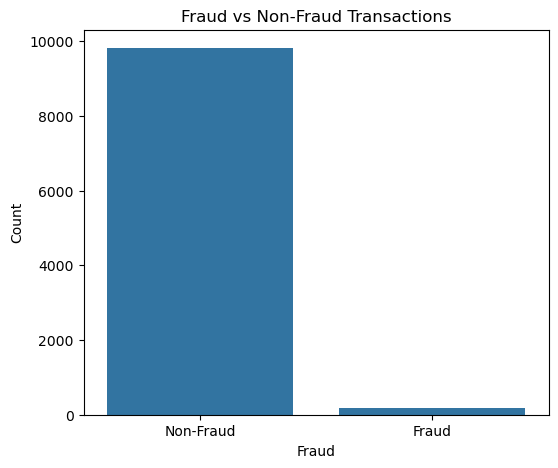

In [16]:
# Fraud vs Non-Fraud Distribution
plt.figure(figsize=(6,5))

sns.countplot(x='is_fraud', data=df)

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Fraud")
plt.ylabel("Count")

plt.xticks([0,1],["Non-Fraud","Fraud"])

plt.show()

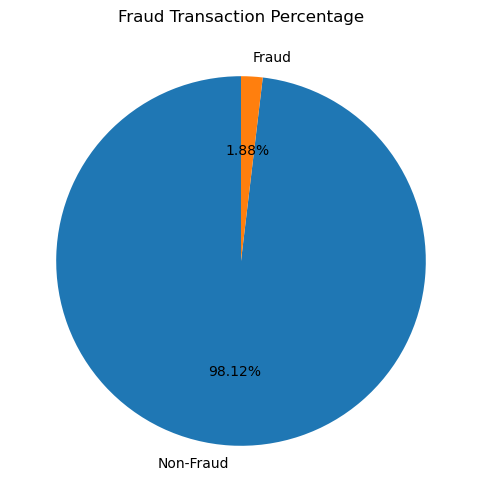

In [17]:
# Percentage of Fraud Transactions
fraud_counts = df['is_fraud'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    fraud_counts,
    labels=['Non-Fraud','Fraud'],
    autopct='%1.2f%%',
    startangle=90
)

plt.title("Fraud Transaction Percentage")

plt.show()

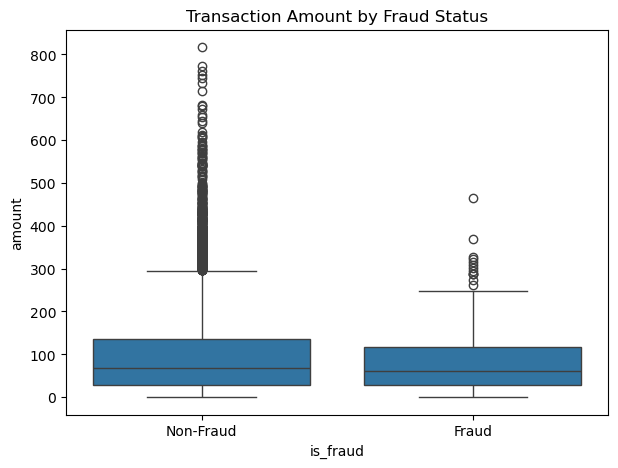

In [18]:
# Boxplot of Amount by Fraud
plt.figure(figsize=(7,5))

sns.boxplot(x='is_fraud',
            y='amount',
            data=df)

plt.xticks([0,1],["Non-Fraud","Fraud"])

plt.title("Transaction Amount by Fraud Status")

plt.show()

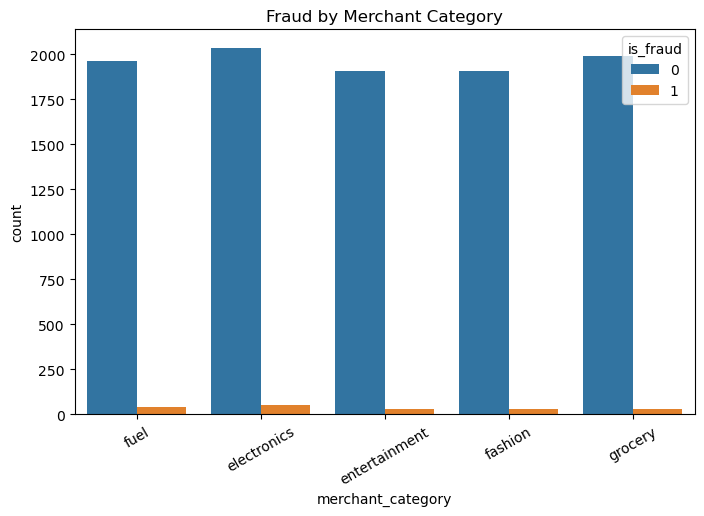

In [19]:
# Fraud by Merchant Category
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='merchant_category',
    hue='is_fraud'
)

plt.title("Fraud by Merchant Category")

plt.xticks(rotation=30)

plt.show()


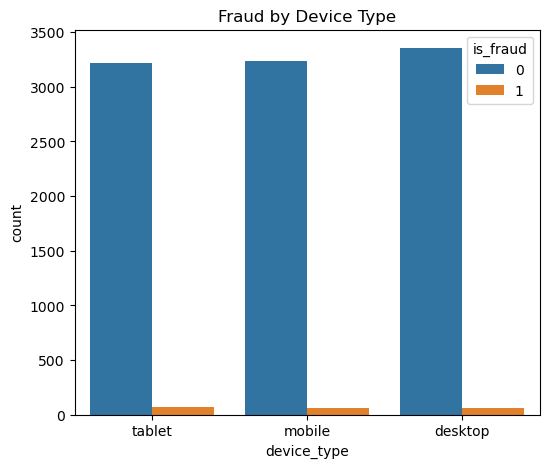

In [20]:
# Fraud by Device Type
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x='device_type',
    hue='is_fraud'
)

plt.title("Fraud by Device Type")

plt.show()

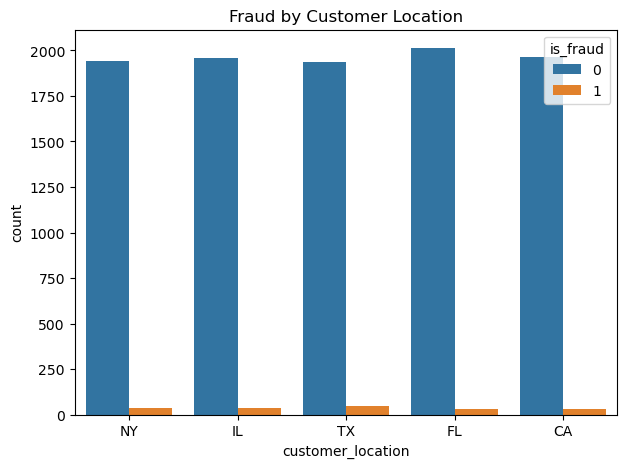

In [21]:
# Fraud by Customer Location
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='customer_location',
    hue='is_fraud'
)

plt.title("Fraud by Customer Location")

plt.show()

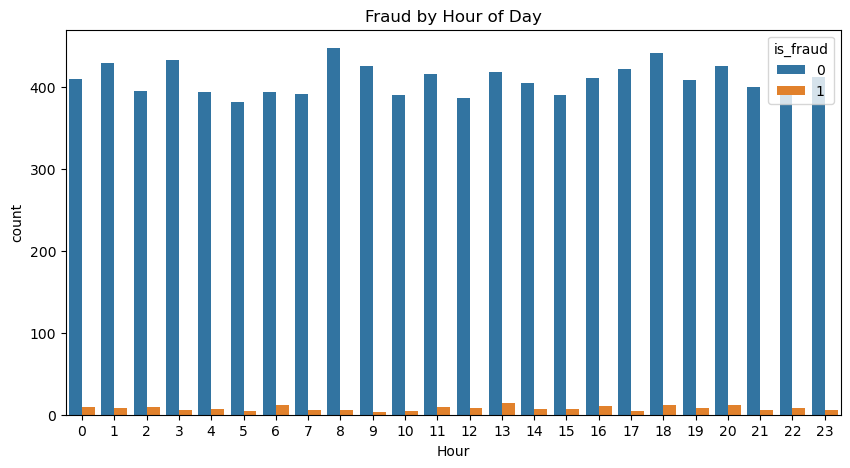

In [22]:
# Fraud by Hour
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='Hour',
    hue='is_fraud'
)

plt.title("Fraud by Hour of Day")

plt.show()

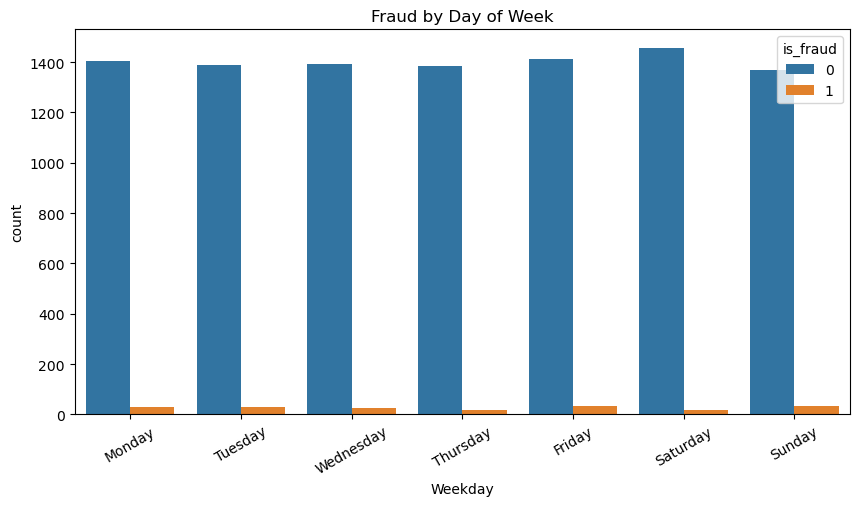

In [23]:
# Fraud by Weekday
order = [
    'Monday','Tuesday','Wednesday',
    'Thursday','Friday',
    'Saturday','Sunday'
]

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='Weekday',
    hue='is_fraud',
    order=order
)

plt.title("Fraud by Day of Week")

plt.xticks(rotation=30)

plt.show()

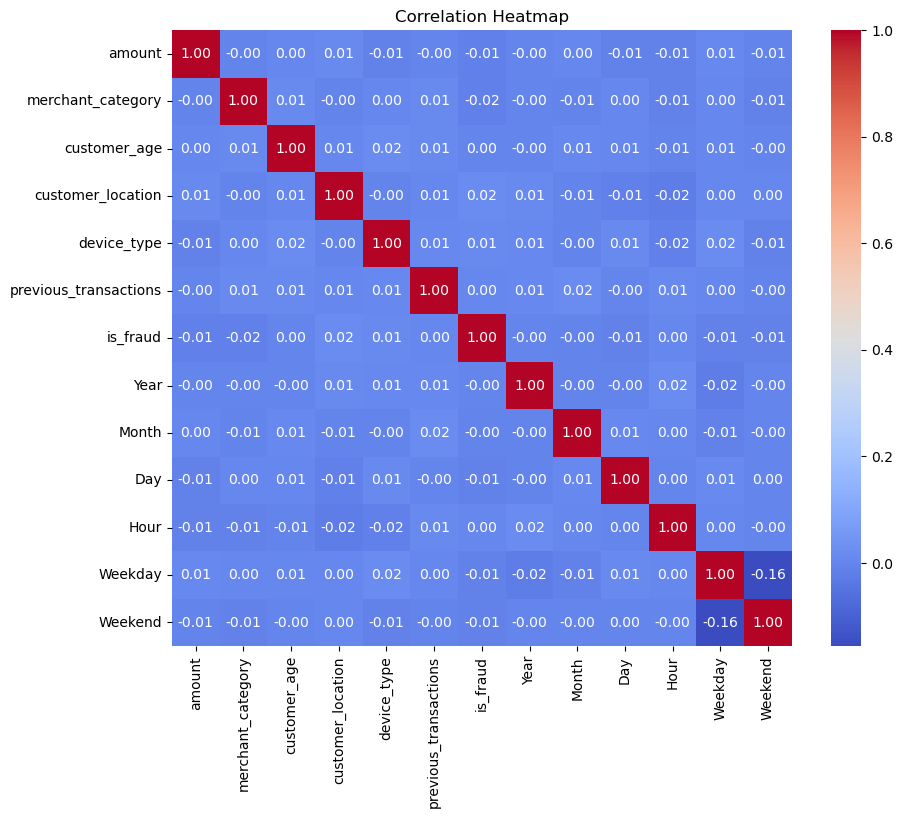

In [24]:
# Correlation Heatmap
corr_df = df.copy()

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in corr_df.select_dtypes(include='object').columns:
    corr_df[col] = encoder.fit_transform(corr_df[col])

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

# Data Preprocessing for Machine Learning

In [25]:
# Create a copy

model_df = df.copy()

# Encode categorical variables

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical_columns = [
    'merchant_category',
    'customer_location',
    'device_type',
    'Weekday'
]

for col in categorical_columns:
    model_df[col] = encoder.fit_transform(model_df[col])

model_df.head()

,amount,merchant_category,customer_age,customer_location,device_type,previous_transactions,is_fraud,Year,Month,Day,Hour,Weekday,Weekend
0,46.93,3,48,3,2,2,0,2022,1,2,6,3,1
1,301.01,0,58,2,1,4,0,2024,9,5,14,4,0
2,131.67,1,23,4,2,2,0,2022,12,7,6,6,0
3,91.29,2,69,1,0,6,0,2022,8,19,3,0,0
4,16.96,2,48,4,2,0,0,2023,4,19,12,6,0


In [26]:
# Separate Features and Target
X = model_df.drop('is_fraud', axis=1)

y = model_df['is_fraud']

In [27]:
print(X.shape)
print(y.shape)

(10000, 12)
(10000,)


In [28]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape)

print("Testing Samples :", X_test.shape)

Training Samples : (8000, 12)
Testing Samples : (2000, 12)


In [29]:
# Standardize Numerical Variables
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [30]:
# Check Class Distribution
print(y_train.value_counts())

is_fraud
0    7850
1     150
Name: count, dtype: int64


In [31]:
# Apply SMOTE
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [32]:
# Check New Distribution
print(pd.Series(y_train_smote).value_counts())

is_fraud
0    7850
1    7850
Name: count, dtype: int64


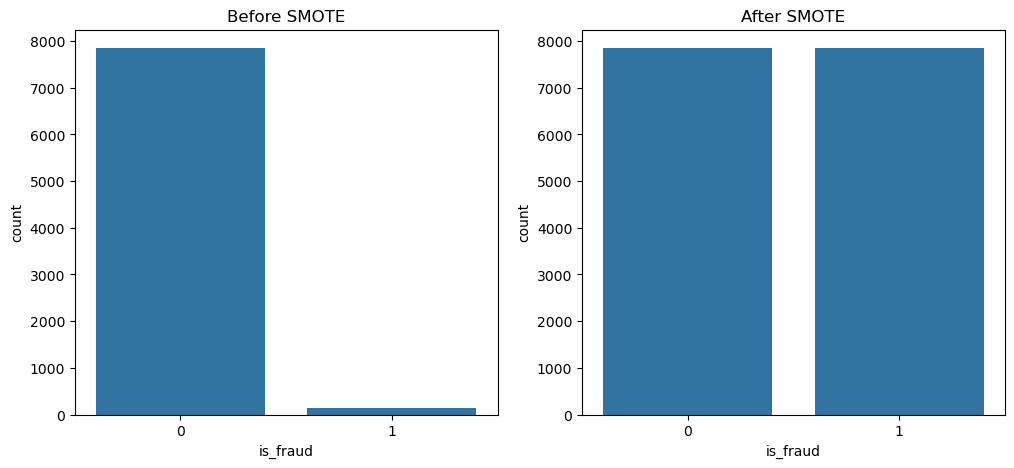

In [33]:
# Visualize Class Balance Before and After SMOTE
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

sns.countplot(x=y_train)

plt.title("Before SMOTE")

plt.subplot(1,2,2)

sns.countplot(x=pd.Series(y_train_smote))

plt.title("After SMOTE")

plt.show()

In [34]:
# Prepare a Results Table
results = pd.DataFrame(
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
)

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC


# Supervised Machine Learning  

## Logistic Regression

In [35]:
# Create Logistic Regression Model
lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [36]:
# Train the Model
lr.fit(
    X_train_smote,
    y_train_smote
)

LogisticRegression(max_iter=1000, random_state=42)

In [37]:
# Predictions

y_pred_lr = lr.predict(X_test_scaled)

# Probability prediction

y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]

In [38]:
# Calculate Performance Metrics
accuracy_lr = accuracy_score(y_test, y_pred_lr)

precision_lr = precision_score(y_test, y_pred_lr)

recall_lr = recall_score(y_test, y_pred_lr)

f1_lr = f1_score(y_test, y_pred_lr)

roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

In [39]:
# Display results
print("Accuracy :", round(accuracy_lr,4))
print("Precision:", round(precision_lr,4))
print("Recall :", round(recall_lr,4))
print("F1 Score :", round(f1_lr,4))
print("ROC AUC :", round(roc_auc_lr,4))

Accuracy : 0.535
Precision: 0.0215
Recall : 0.5263
F1 Score : 0.0412
ROC AUC : 0.5259


In [40]:
# Classification Report
print(classification_report(
    y_test,
    y_pred_lr
))

              precision    recall  f1-score   support

           0       0.98      0.54      0.69      1962
           1       0.02      0.53      0.04        38

    accuracy                           0.54      2000
   macro avg       0.50      0.53      0.37      2000
weighted avg       0.96      0.54      0.68      2000



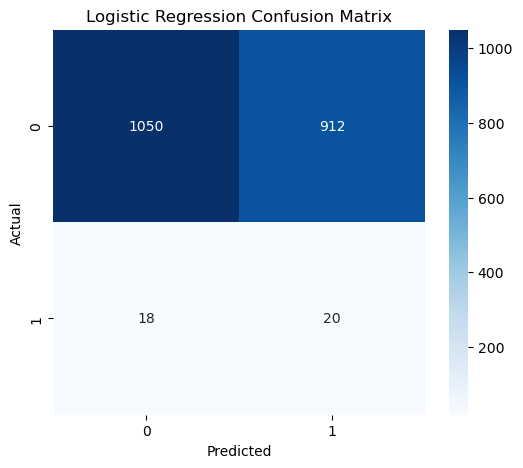

In [41]:
# Confusion Matrix
cm = confusion_matrix(
    y_test,
    y_pred_lr
)

cm
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

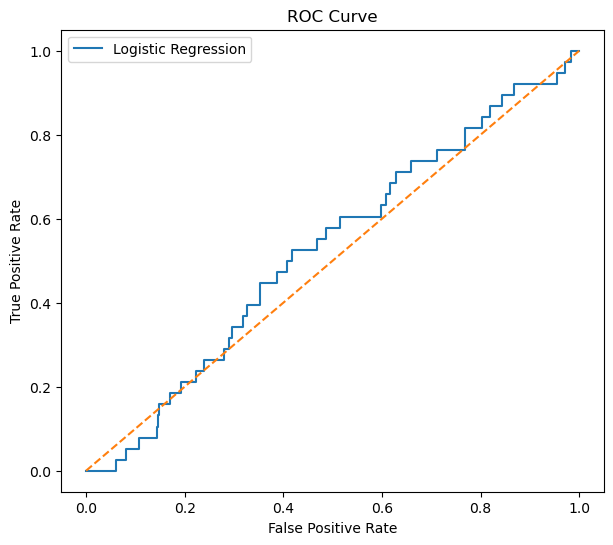

In [42]:
# ROC Curve
fpr, tpr, threshold = roc_curve(
    y_test,
    y_prob_lr
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label="Logistic Regression"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

## Random Forest Classifier

In [43]:
from imblearn.over_sampling import SMOTE

smote_rf = SMOTE(random_state=42)

X_train_rf, y_train_rf = smote_rf.fit_resample(
    X_train,
    y_train
)

print(pd.Series(y_train_rf).value_counts())

is_fraud
0    7850
1    7850
Name: count, dtype: int64


In [44]:
# Create Random Forest model

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

In [45]:
# Train the Model
rf.fit(
    X_train_rf,
    y_train_rf
)

RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)

In [46]:
# Predictions
y_pred_rf = rf.predict(X_test)

y_prob_rf = rf.predict_proba(X_test)[:,1]

In [47]:
# Calculate Evaluation Metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)

precision_rf = precision_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

recall_rf = recall_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

f1_rf = f1_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

roc_auc_rf = roc_auc_score(
    y_test,
    y_prob_rf
)

In [48]:
# Display Results
print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall :", recall_rf)
print("F1 Score :", f1_rf)
print("ROC AUC :", roc_auc_rf)

Accuracy : 0.9565
Precision: 0.0
Recall : 0.0
F1 Score : 0.0
ROC AUC : 0.42217259509630345


In [49]:
# Classification Report
print(classification_report(
    y_test,
    y_pred_rf,
    zero_division=0
))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1962
           1       0.00      0.00      0.00        38

    accuracy                           0.96      2000
   macro avg       0.49      0.49      0.49      2000
weighted avg       0.96      0.96      0.96      2000



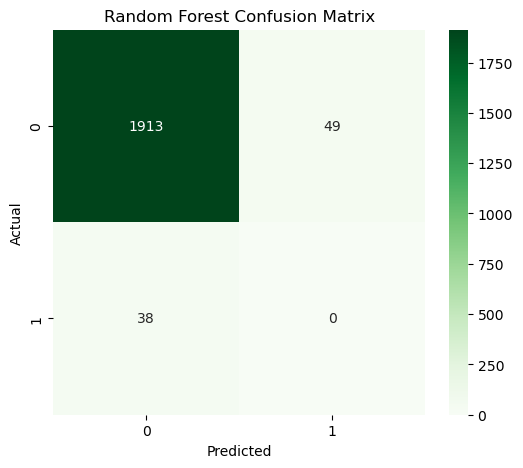

In [50]:
# Confusion Matrix
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)
plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

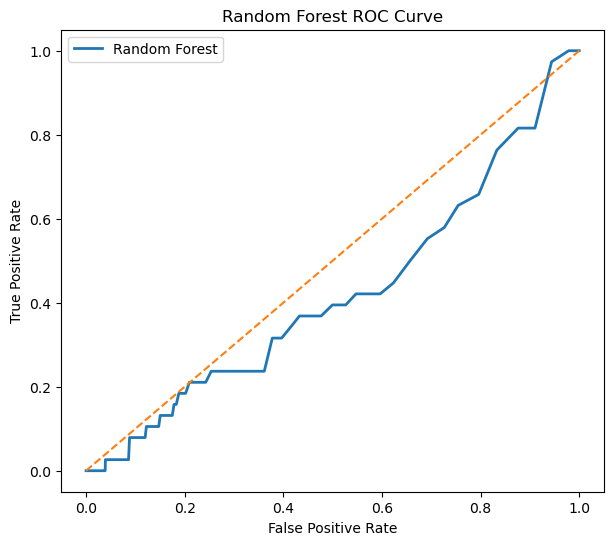

In [51]:
# ROC Curve
fpr_rf, tpr_rf, threshold_rf = roc_curve(
    y_test,
    y_prob_rf
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr_rf,
    tpr_rf,
    linewidth=2,
    label="Random Forest"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("Random Forest ROC Curve")

plt.legend()

plt.show()

In [52]:
# Feature Importance
importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance': rf.feature_importances_

})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
0,amount,0.144604
10,Weekday,0.106638
2,customer_age,0.105193
9,Hour,0.092944
8,Day,0.084487
7,Month,0.075083
11,Weekend,0.073978
1,merchant_category,0.071193
6,Year,0.066902
3,customer_location,0.062734


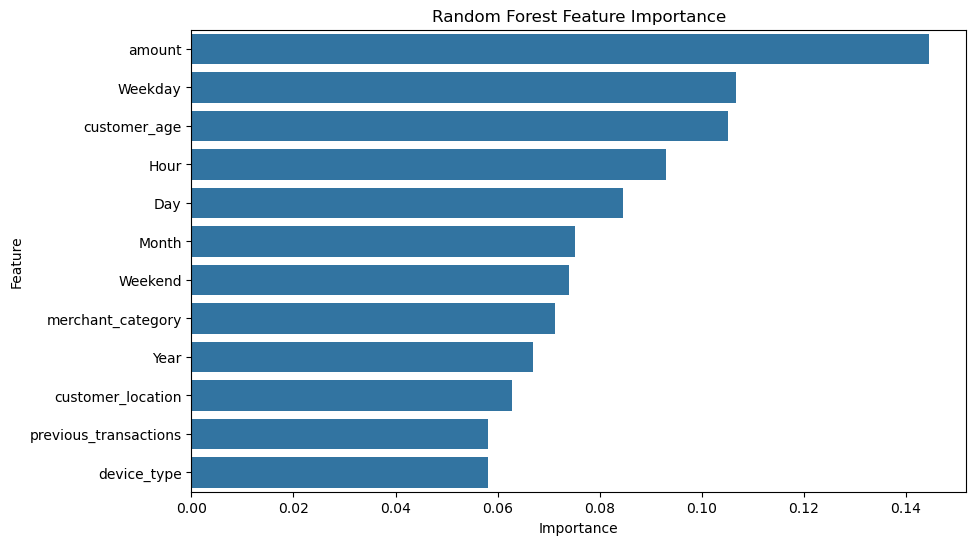

In [53]:
# Plot Feature Importance
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title("Random Forest Feature Importance")

plt.show()

## XGBoost Classifier

In [54]:
from xgboost import XGBClassifier
# Create the Model
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    objective='binary:logistic',
    eval_metric='logloss'
)

In [55]:
# Train the Model
xgb.fit(
    X_train_rf,
    y_train_rf
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [56]:
# Make Predictions
y_pred_xgb = xgb.predict(X_test)

y_prob_xgb = xgb.predict_proba(X_test)[:,1]

In [57]:
# Calculate Performance Metrics
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)

precision_xgb = precision_score(
    y_test,
    y_pred_xgb,
    zero_division=0
)

recall_xgb = recall_score(
    y_test,
    y_pred_xgb,
    zero_division=0
)

f1_xgb = f1_score(
    y_test,
    y_pred_xgb,
    zero_division=0
)

roc_auc_xgb = roc_auc_score(
    y_test,
    y_prob_xgb
)

In [58]:
# Display Results
print("Accuracy :", round(accuracy_xgb,4))
print("Precision:", round(precision_xgb,4))
print("Recall :", round(recall_xgb,4))
print("F1 Score :", round(f1_xgb,4))
print("ROC AUC :", round(roc_auc_xgb,4))

Accuracy : 0.9275
Precision: 0.0
Recall : 0.0
F1 Score : 0.0
ROC AUC : 0.4968


In [59]:
# Classification Report
print(classification_report(
    y_test,
    y_pred_xgb,
    zero_division=0
))

              precision    recall  f1-score   support

           0       0.98      0.95      0.96      1962
           1       0.00      0.00      0.00        38

    accuracy                           0.93      2000
   macro avg       0.49      0.47      0.48      2000
weighted avg       0.96      0.93      0.94      2000



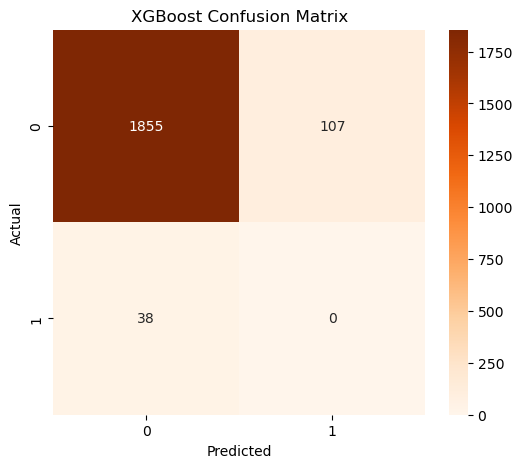

In [60]:
# Confusion Matrix
cm_xgb = confusion_matrix(
    y_test,
    y_pred_xgb
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title("XGBoost Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

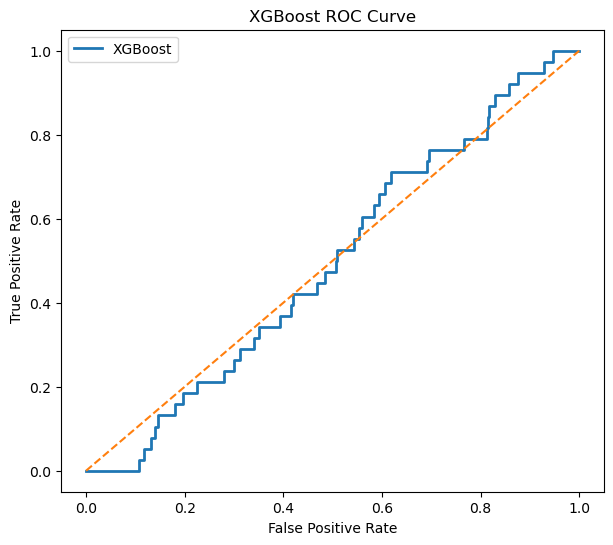

In [61]:
# ROC Curve
fpr_xgb, tpr_xgb, threshold_xgb = roc_curve(
    y_test,
    y_prob_xgb
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr_xgb,
    tpr_xgb,
    linewidth=2,
    label="XGBoost"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("XGBoost ROC Curve")

plt.legend()

plt.show()

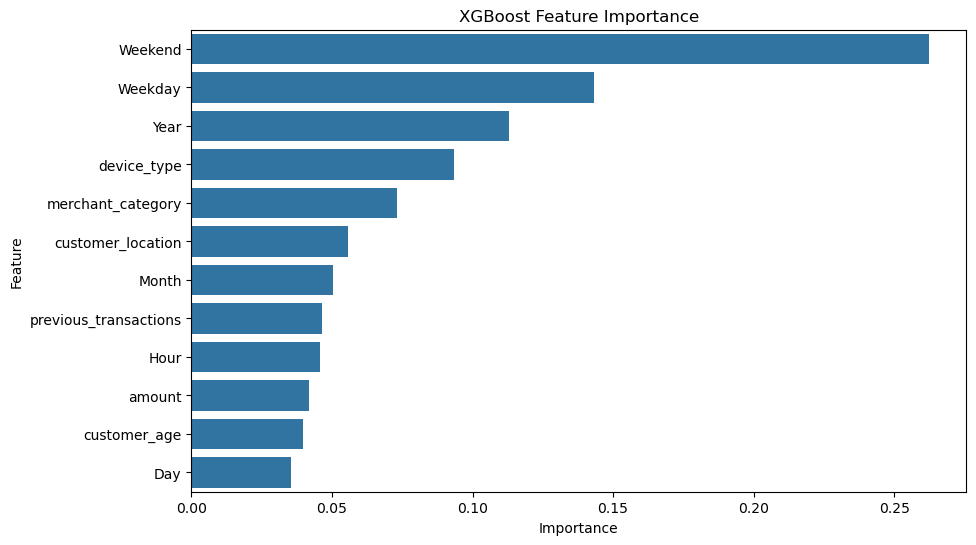

In [62]:
# Feature Importance
importance_xgb = pd.DataFrame({

    'Feature': X.columns,

    'Importance': xgb.feature_importances_

})

importance_xgb = importance_xgb.sort_values(
    by='Importance',
    ascending=False
)
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_xgb,
    x='Importance',
    y='Feature'
)

plt.title("XGBoost Feature Importance")

plt.show()

# Unsupervised Machine Learning Algorithms

## Isolation Forest

In [63]:
# Create Training and Testing Data
# Features only (no target)

X_train_if = X_train.copy()

X_test_if = X_test.copy()

In [64]:
# Create the Model
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=200,
    contamination=0.0188,
    random_state=42
)

In [65]:
# Train the Model
iso.fit(X_train_if)


IsolationForest(contamination=0.0188, n_estimators=200, random_state=42)

In [66]:
# Predict
pred_if = iso.predict(X_test_if)

y_pred_if = np.where(pred_if == -1, 1, 0)

In [67]:
# Anomaly Scores
scores_if = -iso.decision_function(X_test_if)

In [68]:
# Performance Metrics
accuracy_if = accuracy_score(y_test, y_pred_if)

precision_if = precision_score(
    y_test,
    y_pred_if,
    zero_division=0
)

recall_if = recall_score(
    y_test,
    y_pred_if,
    zero_division=0
)

f1_if = f1_score(
    y_test,
    y_pred_if,
    zero_division=0
)

roc_auc_if = roc_auc_score(
    y_test,
    scores_if
)

In [69]:
# Display Results
print("Accuracy :", round(accuracy_if,4))
print("Precision:", round(precision_if,4))
print("Recall :", round(recall_if,4))
print("F1 Score :", round(f1_if,4))
print("ROC AUC :", round(roc_auc_if,4))

Accuracy : 0.9615
Precision: 0.0465
Recall : 0.0526
F1 Score : 0.0494
ROC AUC : 0.5462


In [70]:
# Classification Report
print(classification_report(
    y_test,
    y_pred_if,
    zero_division=0
))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1962
           1       0.05      0.05      0.05        38

    accuracy                           0.96      2000
   macro avg       0.51      0.52      0.51      2000
weighted avg       0.96      0.96      0.96      2000



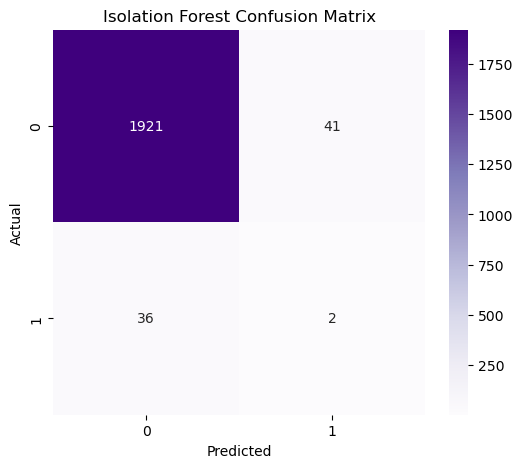

In [71]:
# Confusion Matrix
cm_if = confusion_matrix(
    y_test,
    y_pred_if
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_if,
    annot=True,
    fmt='d',
    cmap='Purples'
)

plt.title("Isolation Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

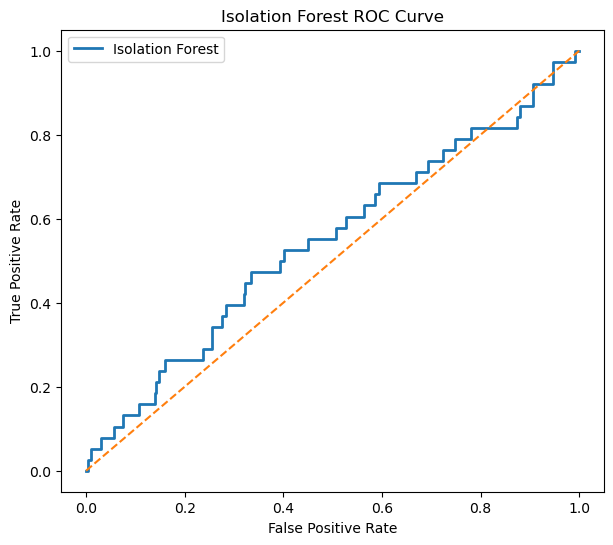

In [72]:
# ROC Curve
fpr_if, tpr_if, _ = roc_curve(
    y_test,
    scores_if
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr_if,
    tpr_if,
    linewidth=2,
    label="Isolation Forest"
)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("Isolation Forest ROC Curve")

plt.legend()

plt.show()

## Local Outlier Factor (LOF)

In [73]:
# Train and Predict
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.0188
)

pred_lof = lof.fit_predict(X_test_scaled)

y_pred_lof = np.where(pred_lof == -1, 1, 0)

In [74]:
# LOF Scores
scores_lof = -lof.negative_outlier_factor_

In [75]:
# Evaluation
accuracy_lof = accuracy_score(y_test, y_pred_lof)

precision_lof = precision_score(
    y_test,
    y_pred_lof,
    zero_division=0
)

recall_lof = recall_score(
    y_test,
    y_pred_lof,
    zero_division=0
)

f1_lof = f1_score(
    y_test,
    y_pred_lof,
    zero_division=0
)

roc_auc_lof = roc_auc_score(
    y_test,
    scores_lof
)

In [76]:
# Classification Report
print(classification_report(
    y_test,
    y_pred_lof,
    zero_division=0
))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1962
           1       0.03      0.03      0.03        38

    accuracy                           0.96      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       0.96      0.96      0.96      2000



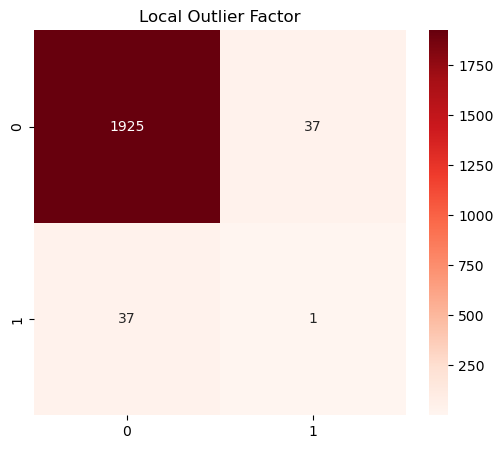

In [77]:
# Confusion Matrix
cm_lof = confusion_matrix(y_test, y_pred_lof)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_lof,
    annot=True,
    fmt='d',
    cmap='Reds'
)

plt.title("Local Outlier Factor")

plt.show()

## K-Means Clustering


In [78]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

kmeans.fit(X_train_scaled)

KMeans(n_clusters=2, n_init=10, random_state=42)

In [79]:
# Predict
clusters = kmeans.predict(X_test_scaled)
cluster_sizes = pd.Series(clusters).value_counts()

fraud_cluster = cluster_sizes.idxmin()

y_pred_kmeans = np.where(
    clusters == fraud_cluster,
    1,
    0
)

In [80]:
# Distances for ROC-AUC
distances = kmeans.transform(X_test_scaled)

scores_kmeans = distances.min(axis=1)

In [81]:
# Evaluation
accuracy_kmeans = accuracy_score(y_test, y_pred_kmeans)

precision_kmeans = precision_score(
    y_test,
    y_pred_kmeans,
    zero_division=0
)

recall_kmeans = recall_score(
    y_test,
    y_pred_kmeans,
    zero_division=0
)

f1_kmeans = f1_score(
    y_test,
    y_pred_kmeans,
    zero_division=0
)

roc_auc_kmeans = roc_auc_score(
    y_test,
    scores_kmeans
)
print("Accuracy :", round(accuracy_kmeans,4))
print("Precision:", round(precision_kmeans,4))
print("Recall :", round(recall_kmeans,4))
print("F1 Score :", round(f1_kmeans,4))
print("ROC AUC :", round(roc_auc_kmeans,4))

Accuracy : 0.5495
Precision: 0.0124
Recall : 0.2895
F1 Score : 0.0238
ROC AUC : 0.5645


In [82]:
# classification report
print(classification_report(
    y_test,
    y_pred_kmeans,
    zero_division=0
))

              precision    recall  f1-score   support

           0       0.98      0.55      0.71      1962
           1       0.01      0.29      0.02        38

    accuracy                           0.55      2000
   macro avg       0.49      0.42      0.37      2000
weighted avg       0.96      0.55      0.69      2000



In [83]:
# Model Comparison 
comparison = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Isolation Forest",
        "Local Outlier Factor",
        "K-Means"
    ],

    "Accuracy": [
        accuracy_lr,
        accuracy_rf,
        accuracy_xgb,
        accuracy_if,
        accuracy_lof,
        accuracy_kmeans
    ],

    "Precision": [
        precision_lr,
        precision_rf,
        precision_xgb,
        precision_if,
        precision_lof,
        precision_kmeans
    ],

    "Recall": [
        recall_lr,
        recall_rf,
        recall_xgb,
        recall_if,
        recall_lof,
        recall_kmeans
    ],

    "F1 Score": [
        f1_lr,
        f1_rf,
        f1_xgb,
        f1_if,
        f1_lof,
        f1_kmeans
    ],

    "ROC-AUC": [
        roc_auc_lr,
        roc_auc_rf,
        roc_auc_xgb,
        roc_auc_if,
        roc_auc_lof,
        roc_auc_kmeans
    ]

})

comparison = comparison.round(4)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.5350,0.0215,0.5263,0.0412,0.5259
1,Random Forest,0.9565,0.0000,0.0000,0.0000,0.4222
2,XGBoost,0.9275,0.0000,0.0000,0.0000,0.4968
3,Isolation Forest,0.9615,0.0465,0.0526,0.0494,0.5462
4,Local Outlier Factor,0.9630,0.0263,0.0263,0.0263,0.5236
5,K-Means,0.5495,0.0124,0.2895,0.0238,0.5645


In [84]:
# Sort by the best model
comparison = comparison.sort_values(
    by="ROC-AUC",
    ascending=False
)

comparison.reset_index(drop=True, inplace=True)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,K-Means,0.5495,0.0124,0.2895,0.0238,0.5645
1,Isolation Forest,0.9615,0.0465,0.0526,0.0494,0.5462
2,Logistic Regression,0.5350,0.0215,0.5263,0.0412,0.5259
3,Local Outlier Factor,0.9630,0.0263,0.0263,0.0263,0.5236
4,XGBoost,0.9275,0.0000,0.0000,0.0000,0.4968
5,Random Forest,0.9565,0.0000,0.0000,0.0000,0.4222
